<a href="https://colab.research.google.com/github/balipacholi/Machine-Learning/blob/main/ANN_Breast_Cancer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Example 3 - Breast Cancer prediction (Binary Classification)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8462 - loss: 0.5076 - val_accuracy: 0.9474 - val_loss: 0.3338
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9407 - loss: 0.2822 - val_accuracy: 0.9474 - val_loss: 0.1971
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9495 - loss: 0.1887 - val_accuracy: 0.9737 - val_loss: 0.1368
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9582 - loss: 0.1409 - val_accuracy: 0.9737 - val_loss: 0.1057
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9692 - loss: 0.1137 - val_accuracy: 0.9825 - val_loss: 0.0890
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9692 - loss: 0.0974 - val_accuracy: 0.9912 - val_loss: 0.0791
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9736 - loss: 0.0861 - val_accuracy: 0.9825 - val_loss: 0.0734
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9736 - loss: 0.0765 - val_accuracy: 0.9912 - val_loss: 0.0700
Ep

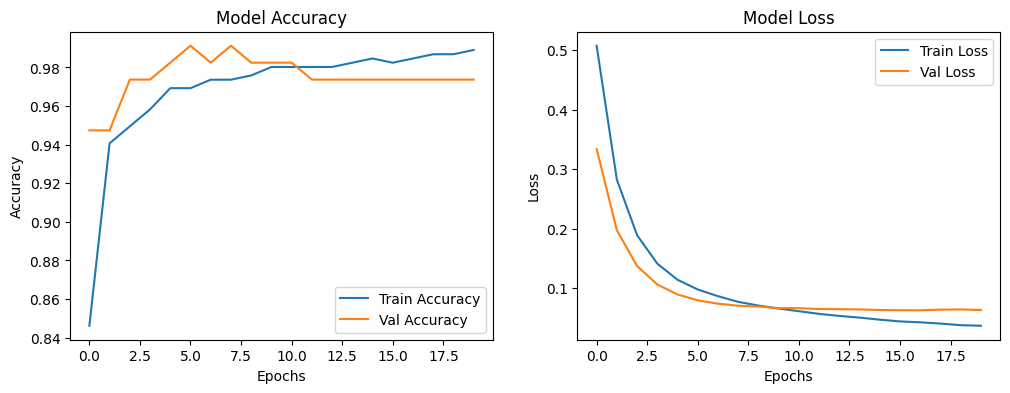

In [13]:
from sklearn.utils import validation
# The breast cancer dataset from scikit-learn contains 569 samples with 30 numerical features extracted
# from digitized images of breast mass tumors. The goal is to classify tumors as malignant (1) or benign (0)
# based on these features. the dataset was originally curated from the Wisconsin Diagnostic Breast Cancer (WDBC)
# dataset and is commonly used for binary classification tasks in machine learning.
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

import numpy as np # numerical operations and arrays.
import tensorflow as tf # library for building and training neural networks.
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt # To create a visuals of the results or predictions
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# load dataset
data = load_breast_cancer()
x, y = data.data, data.target # Features and labels

# Split into training and test sets
# Splits data: 80% training and 20% testing
# random_state=42 → ensures same split every time.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Normalized input data
# Standard scaler formula  scaled = X − mean / std
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train) # Calculates mean & std from training data
x_test = scalar.transform(x_test) # Normalizes training data Because test data should use same scaling as training data.

# Build model
model = models.Sequential([
    layers.Dense(64, activation='relu',input_shape=(x_train.shape[1],)),
    layers.Dense(32, activation='relu'),    # Hidden layer with 32 neurons
    layers.Dense(1, activation='sigmoid') # Sigmoid → used for Binary Classification. as Output between 0 and 1 (probability)
 ])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
# validation_data → evaluates on test data during training
# Returns history object containing loss & accuracy values
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test,y_test))
print(f"History of training model: {history}")

# Evaluate model -> Because evaluate returns loss and accuracy.
x_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test Accuracy: {test_acc * 100:.2f}%')

# Plot accuracy and loss using Matplotlib
plt.figure(figsize=(12,4)) # Creates figure window.

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()